# LAB 04 - Dự Báo Chuỗi Thời Gian (Time Series Forecasting)

**Môn học:** DAT301m - Deep Learning  
**Họ và tên:** Nguyễn Văn Anh Duy  
**MSSV:** SE181823  
**Dữ liệu:** Sunspots.csv — Số vết đen mặt trời trung bình hàng tháng

---

## Mô tả bài toán

Bài toán dự báo chuỗi thời gian sử dụng bộ dữ liệu số vết đen mặt trời (Sunspots) — ghi nhận số lượng vết đen trên bề mặt Mặt Trời theo từng tháng từ năm 1749 đến nay. Mục tiêu là xây dựng và so sánh **2 mô hình** dự báo (Linear Regression, ARIMA) trên **3 chiến lược chia dữ liệu** khác nhau.

## Cấu trúc bài làm

| Phần | Nội dung |
|------|----------|
| **Phần 1** | Tải dữ liệu, khám phá, tạo lag features |
| **Phần 2 (YC2)** | Định nghĩa 7 hàm tính tiêu chí đánh giá |
| **Phần 3** | Hàm hỗ trợ xây dựng ARIMA |
| **Phần 4 (YC1-CS1)** | Chiến lược 1 — Fixed Window (2 mô hình) |
| **Phần 5 (YC1-CS2)** | Chiến lược 2 — Rolling Window (2 mô hình) |
| **Phần 6 (YC1-CS3)** | Chiến lược 3 — Multiple Train-Validation-Test Splits (2 mô hình) |
| **Phần 7** | Tổng hợp và so sánh kết quả |

## Hai mô hình sử dụng

| Mô hình | Loại | Thư viện |
|---------|------|----------|
| **Linear Regression** | Học máy truyền thống — dùng lag features | scikit-learn |
| **ARIMA** | Mô hình thống kê chuỗi thời gian | statsmodels |


## Phần 1: Import Thư Viện và Tải Dữ Liệu

In [1]:
"""Phần 1 — Import thư viện cần thiết."""
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA

# Cấu hình biểu đồ mặc định
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 12

print(f"NumPy {np.__version__} | Pandas {pd.__version__}")


NumPy 2.2.4 | Pandas 2.2.3


In [2]:
"""Tải dữ liệu từ file CSV và đặt chỉ mục thời gian theo tháng (PeriodIndex)."""
df = pd.read_csv("Sunspots.csv", index_col=0, parse_dates=["Date"])
df.columns = ["Date", "Sunspots"]
df = df.set_index("Date")
df.index = pd.DatetimeIndex(df.index).to_period("M")  # tần số theo tháng

print(f"Kích thước dữ liệu : {df.shape}")
print(f"Khoảng thời gian   : {df.index[0]}  →  {df.index[-1]}")
print(f"\nThống kê mô tả:\n{df.describe().T}")

Kích thước dữ liệu : (3235, 1)
Khoảng thời gian   : 1749-01  →  2018-07

Thống kê mô tả:
           count       mean       std  min    25%   50%    75%    max
Sunspots  3235.0  82.481082  67.80519  0.0  24.75  68.3  122.9  398.2


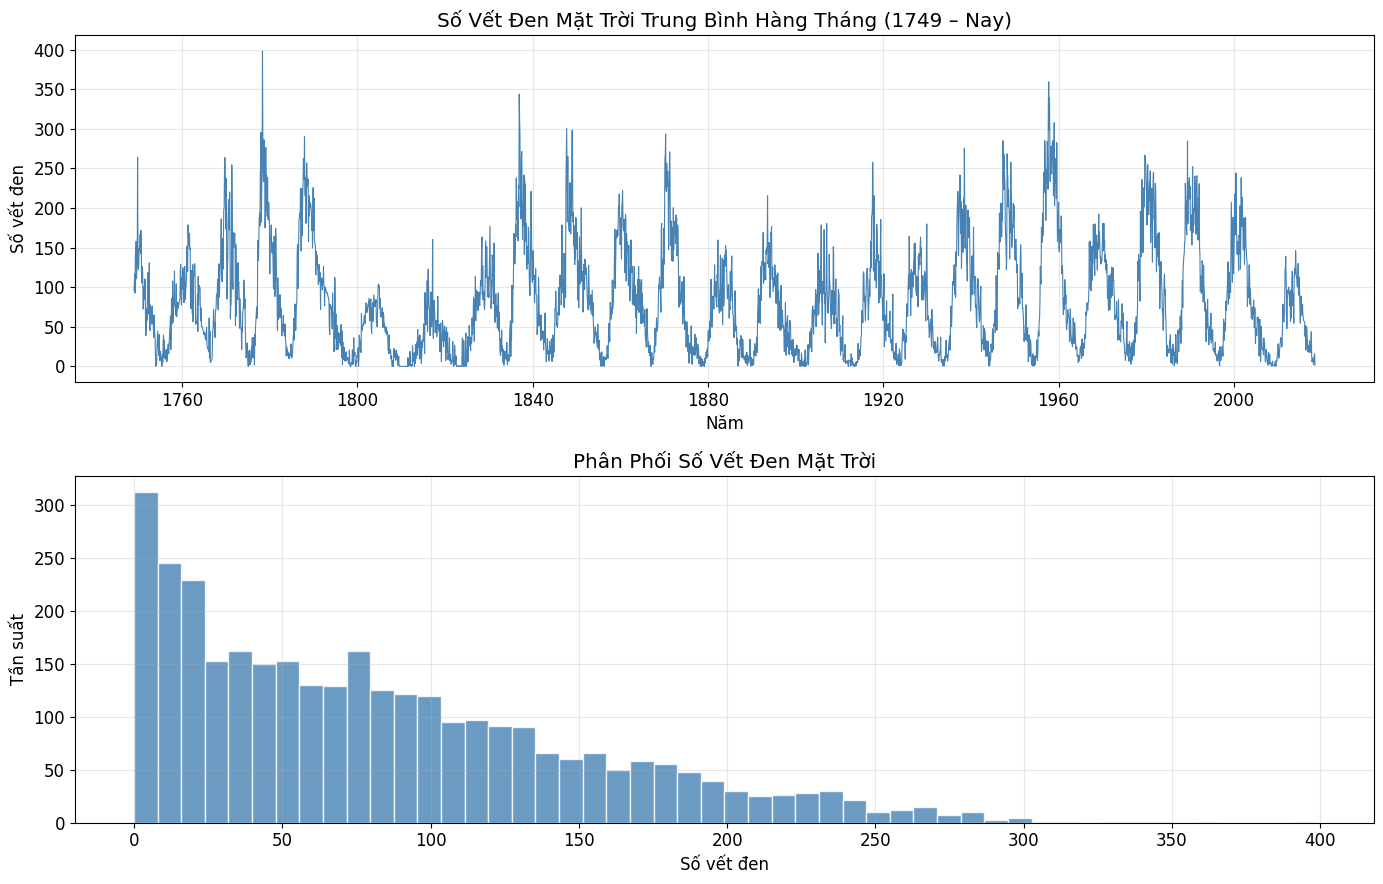

  Min = 0.0  |  Max = 398.2
  Mean = 82.48  |  Std = 67.81
  Tổng số mẫu: 3235


In [3]:
"""Trực quan hóa toàn bộ chuỗi thời gian và phân phối dữ liệu."""
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

# Biểu đồ 1: Chuỗi thời gian
ax1.plot(df.index.to_timestamp(), df["Sunspots"], color="steelblue", linewidth=0.8)
ax1.set(title="Số Vết Đen Mặt Trời Trung Bình Hàng Tháng (1749 – Nay)",
        xlabel="Năm", ylabel="Số vết đen")
ax1.grid(True, alpha=0.3)

# Biểu đồ 2: Phân phối
ax2.hist(df["Sunspots"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax2.set(title="Phân Phối Số Vết Đen Mặt Trời",
        xlabel="Số vết đen", ylabel="Tần suất")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"  Min = {df['Sunspots'].min():.1f}  |  Max = {df['Sunspots'].max():.1f}")
print(f"  Mean = {df['Sunspots'].mean():.2f}  |  Std = {df['Sunspots'].std():.2f}")
print(f"  Tổng số mẫu: {len(df)}")

In [4]:
"""
Tạo đặc trưng trễ (Lag Features) từ chuỗi thời gian.

Ý tưởng: dùng SO_LAG giá trị quá khứ liên tiếp làm đầu vào (X)
để dự đoán giá trị tiếp theo (y).
  lag_1  = giá trị 1 bước trước,
  lag_12 = giá trị 12 bước trước (≈ 1 năm trước).
"""

def tao_lag_features(series, so_lag=12):
    values = series.values
    X = np.array([values[i - so_lag:i] for i in range(so_lag, len(values))])
    y = values[so_lag:]
    return X, y

SO_LAG = 12
X_all, y_all = tao_lag_features(df["Sunspots"], so_lag=SO_LAG)

print(f"X_all shape: {X_all.shape}  (số mẫu × số đặc trưng)")
print(f"y_all shape: {y_all.shape}")
print(f"\nVí dụ mẫu đầu tiên — X[0]: {X_all[0]}")
print(f"Nhãn tương ứng    — y[0]: {y_all[0]}")

X_all shape: (3223, 12)  (số mẫu × số đặc trưng)
y_all shape: (3223,)

Ví dụ mẫu đầu tiên — X[0]: [ 96.7 104.3 116.7  92.8 141.7 139.2 158.  110.5 126.5 125.8 264.3 142. ]
Nhãn tương ứng    — y[0]: 122.2


## Phần 2: Các Hàm Tính Tiêu Chí Đánh Giá (Yêu cầu 2)

Theo yêu cầu, cần tính các tiêu chí sau (ký hiệu: $e_t = y_t - \hat{y}_t$):

| Tiêu chí | Công thức | Ý nghĩa |
|----------|-----------|---------|
| **Errors** | $e_t = y_t - \hat{y}_t$ | Sai số tại từng bước |
| **MSE** | $\dfrac{1}{n}\displaystyle\sum_{t} e_t^2$ | Trung bình bình phương sai số |
| **RMSE** | $\sqrt{\text{MSE}}$ | Cùng đơn vị với dữ liệu gốc |
| **MAE** | $\dfrac{1}{n}\displaystyle\sum_{t} \lvert e_t \rvert$ | Trung bình trị tuyệt đối sai số |
| **MAPE** | $\dfrac{100}{n}\displaystyle\sum_{t} \dfrac{\lvert e_t \rvert}{\lvert y_t \rvert}$ | Sai số tương đối theo phần trăm |
| **Forecast Bias** | $\dfrac{1}{n}\displaystyle\sum_{t} e_t$ | Xu hướng dự báo quá cao / quá thấp |
| **PFA** | $100 - \text{MAPE}$ | Độ chính xác tổng thể (%) |

In [5]:
"""Định nghĩa các hàm tính tiêu chí đánh giá dự báo."""

import numpy as np

def tinh_sai_so(y_thuc, y_du_bao):
    """Sai số từng bước: e_t = y_t − ŷ_t"""
    return np.asarray(y_thuc) - np.asarray(y_du_bao)

def tinh_mse(y, yhat):
    """Mean Squared Error — phạt nặng sai số lớn."""
    return np.mean(tinh_sai_so(y, yhat) ** 2)

def tinh_rmse(y, yhat):
    """Root MSE — cùng đơn vị với dữ liệu gốc."""
    return np.sqrt(tinh_mse(y, yhat))

def tinh_mae(y, yhat):
    """Mean Absolute Error — ít nhạy cảm với ngoại lệ hơn RMSE."""
    return np.mean(np.abs(tinh_sai_so(y, yhat)))

def tinh_mape(y, yhat):
    """Mean Absolute Percentage Error (%) — không phụ thuộc đơn vị đo."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    mask = y != 0          # tránh chia cho 0
    return 100.0 * np.mean(np.abs((y[mask] - yhat[mask]) / y[mask]))

def tinh_forecast_bias(y, yhat):
    """Forecast Bias — >0: dự báo thấp hơn thực tế; <0: dự báo cao hơn."""
    return np.mean(tinh_sai_so(y, yhat))

def tinh_pfa(y, yhat):
    """Percentage Forecast Accuracy (%) = 100 − MAPE."""
    return 100.0 - tinh_mape(y, yhat)


def danh_gia(y, yhat, ten="Mô hình"):
    """Tính toàn bộ tiêu chí, in kết quả và trả về dict."""
    metrics = {
        "Mô hình"      : ten,
        "MSE"          : round(tinh_mse(y, yhat), 4),
        "RMSE"         : round(tinh_rmse(y, yhat), 4),
        "MAE"          : round(tinh_mae(y, yhat), 4),
        "MAPE (%)"     : round(tinh_mape(y, yhat), 2),
        "Forecast Bias": round(tinh_forecast_bias(y, yhat), 4),
        "PFA (%)"      : round(tinh_pfa(y, yhat), 2),
    }
    print(f"\n{'='*55}")
    print(f"  {ten}")
    print(f"{'='*55}")
    for k, v in metrics.items():
        if k != "Mô hình":
            print(f"  {k:<22}: {v}")
    return metrics

print("Định nghĩa hàm đánh giá hoàn tất.")

Định nghĩa hàm đánh giá hoàn tất.


## Phần 3: Hàm Hỗ Trợ Xây Dựng ARIMA

Định nghĩa hàm wrapper `arima_predict(y_train, n)` để các chiến lược chia dữ liệu dùng chung mà không cần lặp lại code huấn luyện mô hình.


In [6]:
"""Phần 3 — Hàm wrapper cho ARIMA."""

def arima_predict(y_train, n_forecast, order=(5, 1, 0)):
    """
    Huấn luyện ARIMA(p,d,q) trên y_train (mảng 1-D),
    trả về mảng dự báo n_forecast bước tiếp theo.
    """
    fitted = ARIMA(y_train, order=order).fit()
    return np.asarray(fitted.forecast(steps=n_forecast))

print("Hàm arima_predict() đã sẵn sàng.")


Hàm arima_predict() đã sẵn sàng.


## Phần 4: Chiến Lược 1 — Fixed Window (Yêu cầu 1)

Chia dữ liệu thành **3 phần cố định** theo tỉ lệ:

| Tập | Tỉ lệ | Vai trò |
|-----|-------|---------|
| Train | 80% đầu | Mô hình học từ lịch sử |
| Validation | 10% giữa | Dự phòng tinh chỉnh siêu tham số |
| Test | 10% cuối | Đánh giá trên dữ liệu chưa thấy |

```
|──────────────── Train (80%) ────────────────|── Val (10%) ──|── Test (10%) ──|
```

Cả 2 mô hình đều được huấn luyện trên cùng tập Train và đánh giá trên tập Test.

**Ưu điểm:** Đơn giản, dễ triển khai, train nhiều dữ liệu nhất.  
**Nhược điểm:** Kết quả phụ thuộc vào điểm cắt — không phản ánh hiệu quả tổng quát.


Train : 2578 mẫu (80.0%)
Val   :  322 mẫu (10.0%)
Test  :  323 mẫu (10.0%)


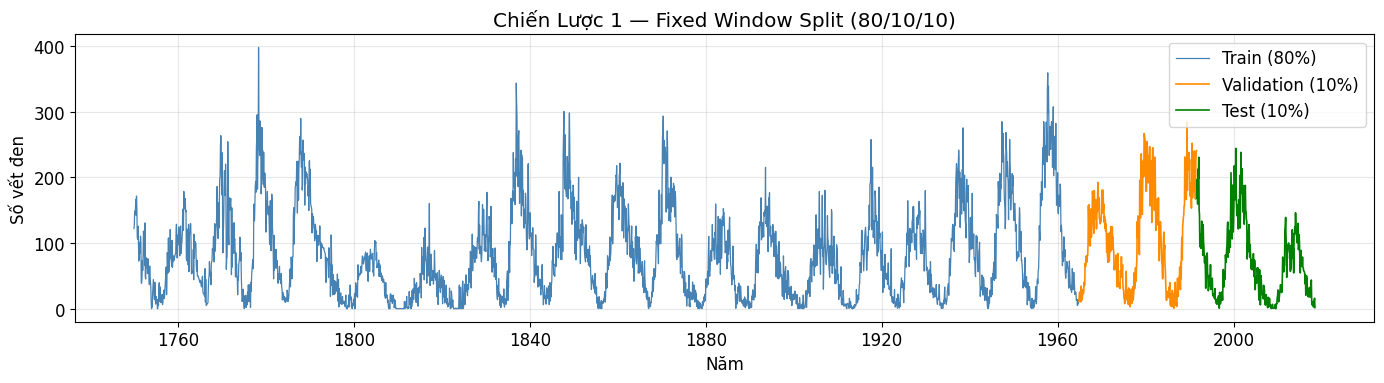


[1] Linear Regression

  CS1 — LR (Fixed Window)
  MSE                   : 435.8495
  RMSE                  : 20.877
  MAE                   : 14.8923
  MAPE (%)              : 62.81
  Forecast Bias         : -1.5344
  PFA (%)               : 37.19

[2] ARIMA(5,1,0) — huấn luyện trên tập Train...

  CS1 — ARIMA (Fixed Window)
  MSE                   : 7018.2141
  RMSE                  : 83.7748
  MAE                   : 62.5996
  MAPE (%)              : 113.17
  Forecast Bias         : 61.313
  PFA (%)               : -13.17


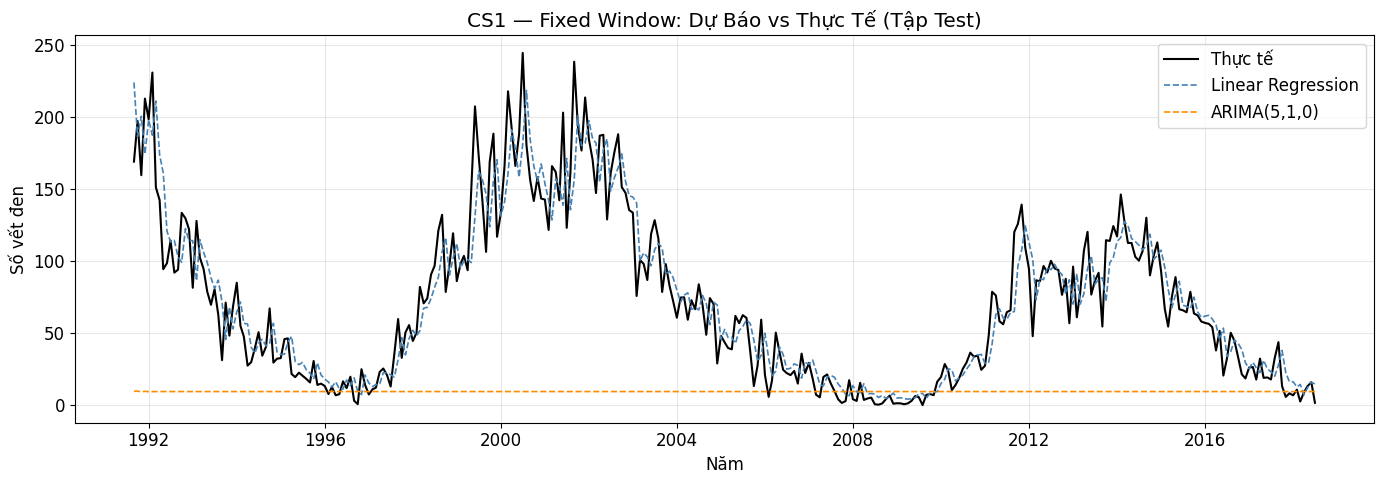


So sánh các mô hình — Chiến lược 1 (Fixed Window):
                                  MSE     RMSE      MAE  MAPE (%)  Forecast Bias  PFA (%)
Mô hình                                                                                  
CS1 — LR (Fixed Window)      435.8495  20.8770  14.8923     62.81        -1.5344    37.19
CS1 — ARIMA (Fixed Window)  7018.2141  83.7748  62.5996    113.17        61.3130   -13.17


In [7]:
"""Chiến lược 1: Fixed Window — chia cố định 80/10/10, đánh giá 2 mô hình."""

n        = len(X_all)
n_train  = int(n * 0.80)
n_val    = int(n * 0.10)

X_train, y_train = X_all[:n_train],               y_all[:n_train]
X_val,   y_val   = X_all[n_train:n_train+n_val],  y_all[n_train:n_train+n_val]
X_test,  y_test  = X_all[n_train+n_val:],         y_all[n_train+n_val:]

ts        = df.index[SO_LAG:].to_timestamp()
train_idx = ts[:n_train]
val_idx   = ts[n_train:n_train+n_val]
test_idx  = ts[n_train+n_val:]

print(f"Train : {len(X_train):4d} mẫu ({len(X_train)/n*100:.1f}%)")
print(f"Val   : {len(X_val):4d} mẫu ({len(X_val)/n*100:.1f}%)")
print(f"Test  : {len(X_test):4d} mẫu ({len(X_test)/n*100:.1f}%)")

# ── Trực quan hóa phân vùng ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_idx, y_train, color="steelblue",  lw=0.9, label="Train (80%)")
ax.plot(val_idx,   y_val,   color="darkorange", lw=1.2, label="Validation (10%)")
ax.plot(test_idx,  y_test,  color="green",      lw=1.2, label="Test (10%)")
ax.set(title="Chiến Lược 1 — Fixed Window Split (80/10/10)",
       xlabel="Năm", ylabel="Số vết đen")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── [1] Linear Regression ────────────────────────────────────────────────────
print("\n[1] Linear Regression")
mo_hinh_lr    = LinearRegression().fit(X_train, y_train)
y_pred_fw_lr  = mo_hinh_lr.predict(X_test)
ket_qua_fw_lr = danh_gia(y_test, y_pred_fw_lr, "CS1 — LR (Fixed Window)")

# ── [2] ARIMA ────────────────────────────────────────────────────────────────
print("\n[2] ARIMA(5,1,0) — huấn luyện trên tập Train...")
y_pred_fw_arima  = arima_predict(y_train, len(y_test), order=(5, 1, 0))
ket_qua_fw_arima = danh_gia(y_test, y_pred_fw_arima, "CS1 — ARIMA (Fixed Window)")

# ── Biểu đồ so sánh dự báo vs thực tế (Tập Test) ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_idx, y_test,          color="black",      lw=1.5,           label="Thực tế")
ax.plot(test_idx, y_pred_fw_lr,    color="steelblue",  lw=1.2, ls="--", label="Linear Regression")
ax.plot(test_idx, y_pred_fw_arima, color="darkorange", lw=1.2, ls="--", label="ARIMA(5,1,0)")
ax.set(title="CS1 — Fixed Window: Dự Báo vs Thực Tế (Tập Test)",
       xlabel="Năm", ylabel="Số vết đen")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Bảng so sánh tiêu chí ────────────────────────────────────────────────────
df_fw = pd.DataFrame([ket_qua_fw_lr, ket_qua_fw_arima]).set_index("Mô hình")
print("\nSo sánh các mô hình — Chiến lược 1 (Fixed Window):")
print(df_fw.to_string())


## Phần 5: Chiến Lược 2 — Rolling Window (Yêu cầu 1)

Thay vì dùng toàn bộ lịch sử, mô hình học trên một **cửa sổ** có kích thước cố định (`WINDOW_SIZE`) trượt dần theo thời gian với bước nhảy `STEP_SIZE`.

```
Bước 1: [────── W ──────| P P P ... P ]
Bước 2:         [────── W ──────| P P P ... P ]
Bước 3:                 [────── W ──────| P P P ... P ]
          W = cửa sổ huấn luyện,  P = nhóm điểm dự báo (STEP_SIZE)
```

**Cài đặt:** `WINDOW_SIZE = 120 tháng (≈10 năm)`, `STEP_SIZE = 100 tháng`.  
Sau mỗi lần dịch chuyển, cả 2 mô hình được **huấn luyện lại từ đầu** trên cửa sổ mới.

**Ưu điểm:** Mô hình luôn phản ánh xu hướng cục bộ gần nhất — phù hợp khi có *concept drift*.  
**Nhược điểm:** Chi phí tính toán cao do phải huấn luyện lại nhiều lần.


WINDOW_SIZE=120 | STEP_SIZE=100 | Số lần train ≈ 31

[1] Linear Regression — Rolling Window...

  CS2 — LR (Rolling Window)
  MSE                   : 738.9293
  RMSE                  : 27.1833
  MAE                   : 19.5775
  MAPE (%)              : 78.43
  Forecast Bias         : 0.3361
  PFA (%)               : 21.57

[2] ARIMA — Rolling Window...

  CS2 — ARIMA (Rolling Window)
  MSE                   : 8136.5758
  RMSE                  : 90.203
  MAE                   : 71.3383
  MAPE (%)              : 476.08
  Forecast Bias         : 12.2021
  PFA (%)               : -376.08


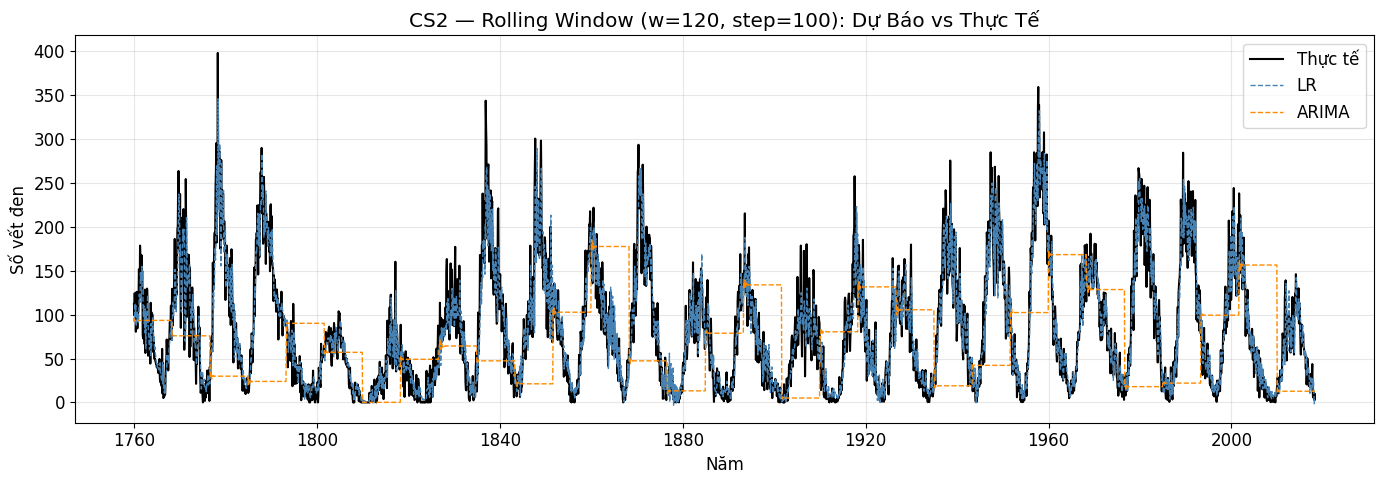


So sánh các mô hình — Chiến lược 2 (Rolling Window):
                                    MSE     RMSE      MAE  MAPE (%)  Forecast Bias  PFA (%)
Mô hình                                                                                    
CS2 — LR (Rolling Window)      738.9293  27.1833  19.5775     78.43         0.3361    21.57
CS2 — ARIMA (Rolling Window)  8136.5758  90.2030  71.3383    476.08        12.2021  -376.08


In [8]:
"""Chiến lược 2: Rolling Window — cửa sổ trượt, re-train sau mỗi STEP_SIZE bước."""

WINDOW_SIZE = 120    # cửa sổ huấn luyện = 120 tháng ≈ 10 năm
STEP_SIZE   = 100    # dự báo 100 bước tiếp theo sau mỗi lần train

n_batches = (len(X_all) - WINDOW_SIZE) // STEP_SIZE
print(f"WINDOW_SIZE={WINDOW_SIZE} | STEP_SIZE={STEP_SIZE} | Số lần train ≈ {n_batches}")


def rolling_window_forecast(model_type, X, y, window, step, **kw):
    """
    Batch rolling: huấn luyện mô hình trên cửa sổ [s : s+window],
    dự báo [s+window : s+window+step], dịch cửa sổ thêm `step` bước.
    - model_type: 'lr' | 'arima'
    """
    y_true, y_pred = [], []
    for s in range(0, len(X) - window - step + 1, step):
        Xw, yw = X[s:s+window], y[s:s+window]
        Xt, yt = X[s+window:s+window+step], y[s+window:s+window+step]

        if model_type == "lr":
            preds = LinearRegression().fit(Xw, yw).predict(Xt)
        elif model_type == "arima":
            preds = arima_predict(yw, len(yt), order=kw.get("order", (5, 1, 0)))
        y_true.extend(yt); y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)


# ── [1] Linear Regression ────────────────────────────────────────────────────
print("\n[1] Linear Regression — Rolling Window...")
y_true_roll, y_pred_roll_lr = rolling_window_forecast("lr", X_all, y_all, WINDOW_SIZE, STEP_SIZE)
ket_qua_roll_lr = danh_gia(y_true_roll, y_pred_roll_lr, "CS2 — LR (Rolling Window)")

# ── [2] ARIMA ────────────────────────────────────────────────────────────────
print("\n[2] ARIMA — Rolling Window...")
_, y_pred_roll_arima = rolling_window_forecast("arima", X_all, y_all, WINDOW_SIZE, STEP_SIZE)
ket_qua_roll_arima = danh_gia(y_true_roll, y_pred_roll_arima, "CS2 — ARIMA (Rolling Window)")

# ── Biểu đồ so sánh ──────────────────────────────────────────────────────────
ts_start = SO_LAG + WINDOW_SIZE
ts_roll  = df.index[ts_start : ts_start + len(y_true_roll)].to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_roll, y_true_roll,       color="black",      lw=1.5,           label="Thực tế")
ax.plot(ts_roll, y_pred_roll_lr,    color="steelblue",  lw=1.0, ls="--", label="LR")
ax.plot(ts_roll, y_pred_roll_arima, color="darkorange", lw=1.0, ls="--", label="ARIMA")
ax.set(title=f"CS2 — Rolling Window (w={WINDOW_SIZE}, step={STEP_SIZE}): Dự Báo vs Thực Tế",
       xlabel="Năm", ylabel="Số vết đen")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Bảng so sánh ─────────────────────────────────────────────────────────────
df_roll = pd.DataFrame([ket_qua_roll_lr, ket_qua_roll_arima]).set_index("Mô hình")
print("\nSo sánh các mô hình — Chiến lược 2 (Rolling Window):")
print(df_roll.to_string())


## Phần 6: Chiến Lược 3 — Multiple Train-Validation-Test Splits (Yêu cầu 1)

Chia dữ liệu thành **K khúc** (block) thời gian **không chồng chéo**. Mỗi khúc được chia nội bộ thành Train / Val / Test và 2 mô hình được huấn luyện + đánh giá riêng trên từng khúc.

```
|────── Khúc 1 ──────|────── Khúc 2 ──────|────── Khúc 3 ──────|
| Train | Val | Test | | Train | Val | Test | | Train | Val | Test |
```

**Ưu điểm:** Kết quả tin cậy hơn vì đánh giá qua nhiều giai đoạn lịch sử khác nhau.  
**Nhược điểm:** Mỗi khúc nhỏ hơn → mô hình có ít dữ liệu train hơn so với Fixed Window.


Chiến lược 3 — 3 khúc | Train=70% Val=15% Test=15%

  Khúc 1/3: Train=751 | Val=161 | Test=162

  Khúc 1/3 — LR
  MSE                   : 962.8507
  RMSE                  : 31.0298
  MAE                   : 23.215
  MAPE (%)              : 42.98
  Forecast Bias         : 2.0158
  PFA (%)               : 57.02

  Khúc 1/3 — ARIMA
  MSE                   : 15474.2847
  RMSE                  : 124.3957
  MAE                   : 102.8137
  MAPE (%)              : 96.65
  Forecast Bias         : 102.8137
  PFA (%)               : 3.35
  Khúc 2/3: Train=751 | Val=161 | Test=162

  Khúc 2/3 — LR
  MSE                   : 695.3517
  RMSE                  : 26.3695
  MAE                   : 19.8778
  MAPE (%)              : 54.59
  Forecast Bias         : 0.6726
  PFA (%)               : 45.41

  Khúc 2/3 — ARIMA
  MSE                   : 9050.0397
  RMSE                  : 95.1317
  MAE                   : 79.1607
  MAPE (%)              : 92.78
  Forecast Bias         : 78.9233
  PFA (%)     

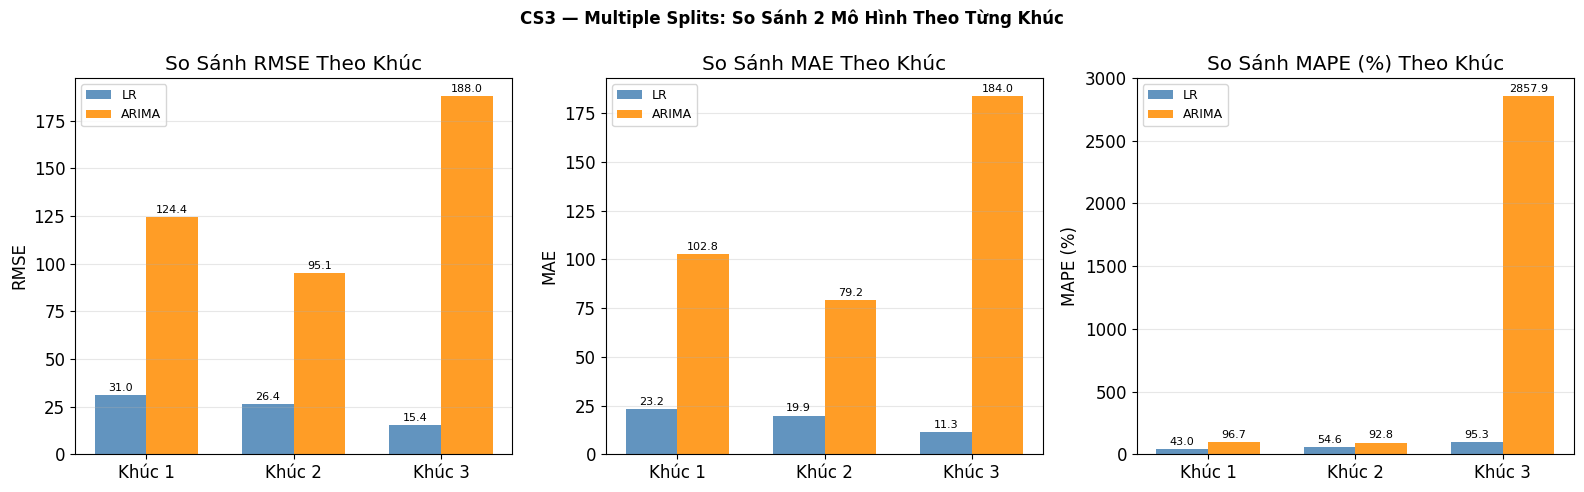

In [9]:
"""Chiến lược 3: Multiple Train-Validation-Test Splits — K khúc, 2 mô hình."""

SO_KHUC  = 3
TY_TRAIN = 0.70
TY_VAL   = 0.15
# TY_TEST = 0.15 (phần còn lại)


def multiple_splits(X, y, so_khuc=3, ty_train=0.70, ty_val=0.15):
    """
    Chia X/y thành `so_khuc` khúc; trong mỗi khúc chia Train/Val/Test.
    Trả về 2 list kết quả tương ứng với LR và ARIMA.
    """
    n_total    = len(X)
    kich_thuoc = n_total // so_khuc
    kq_lr, kq_arima = [], []

    print(f"Chiến lược 3 — {so_khuc} khúc | Train={ty_train*100:.0f}% "
          f"Val={ty_val*100:.0f}% Test={(1-ty_train-ty_val)*100:.0f}%\n")

    for k in range(so_khuc):
        s = k * kich_thuoc
        e = (k + 1) * kich_thuoc if k < so_khuc - 1 else n_total
        Xk, yk = X[s:e], y[s:e]
        nk = len(Xk)
        nt, nv = int(nk * ty_train), int(nk * ty_val)

        Xtr, ytr = Xk[:nt],    yk[:nt]
        Xte, yte = Xk[nt+nv:], yk[nt+nv:]

        label = f"Khúc {k+1}/{so_khuc}"
        print(f"  {label}: Train={nt} | Val={nv} | Test={len(yte)}")

        # Linear Regression
        lr_pred = LinearRegression().fit(Xtr, ytr).predict(Xte)
        kq_lr.append(danh_gia(yte, lr_pred, f"{label} — LR"))

        # ARIMA
        arima_pred = arima_predict(ytr, len(yte), order=(5, 1, 0))
        kq_arima.append(danh_gia(yte, arima_pred, f"{label} — ARIMA"))

    return kq_lr, kq_arima


ket_qua_ms_lr, ket_qua_ms_arima = multiple_splits(
    X_all, y_all, so_khuc=SO_KHUC, ty_train=TY_TRAIN, ty_val=TY_VAL
)

# ── Bảng tổng hợp ────────────────────────────────────────────────────────────
df_ms_lr    = pd.DataFrame(ket_qua_ms_lr).set_index("Mô hình")
df_ms_arima = pd.DataFrame(ket_qua_ms_arima).set_index("Mô hình")

# ── Biểu đồ so sánh RMSE/MAE/MAPE giữa 2 mô hình theo từng khúc ─────────────
x    = np.arange(SO_KHUC)
w    = 0.35
nhan = [f"Khúc {i+1}" for i in range(SO_KHUC)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
tieu_chi = ["RMSE", "MAE", "MAPE (%)"]

for ax, tc in zip(axes, tieu_chi):
    b1 = ax.bar(x - w/2, df_ms_lr[tc],    width=w, color="steelblue",  label="LR",    alpha=0.85)
    b2 = ax.bar(x + w/2, df_ms_arima[tc], width=w, color="darkorange", label="ARIMA", alpha=0.85)
    ax.set(title=f"So Sánh {tc} Theo Khúc", xticks=x, xticklabels=nhan, ylabel=tc)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")
    for bar in [b1, b2]:
        for b in bar:
            h = b.get_height()
            ax.annotate(f"{h:.1f}", xy=(b.get_x() + b.get_width()/2, h),
                        xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

plt.suptitle("CS3 — Multiple Splits: So Sánh 2 Mô Hình Theo Từng Khúc",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## Phần 7: Tổng Hợp và So Sánh Kết Quả


BẢNG TỔNG HỢP KẾT QUẢ (lag=12, LinearRegression / ARIMA(5,1,0))
                                         MSE      RMSE       MAE  MAPE (%)  Forecast Bias  PFA (%)
Mô hình                                                                                           
CS1 — LR (Fixed Window)             435.8495   20.8770   14.8923     62.81        -1.5344    37.19
CS1 — ARIMA (Fixed Window)         7018.2141   83.7748   62.5996    113.17        61.3130   -13.17
CS2 — LR (Rolling Window)           738.9293   27.1833   19.5775     78.43         0.3361    21.57
CS2 — ARIMA (Rolling Window)       8136.5758   90.2030   71.3383    476.08        12.2021  -376.08
CS3 — LR (Multiple Splits TB)       631.8293   24.2678   18.1444     64.30        -0.0464    35.70
CS3 — ARIMA (Multiple Splits TB)  19952.6651  135.8333  121.9874   1015.78        -0.7503  -915.78


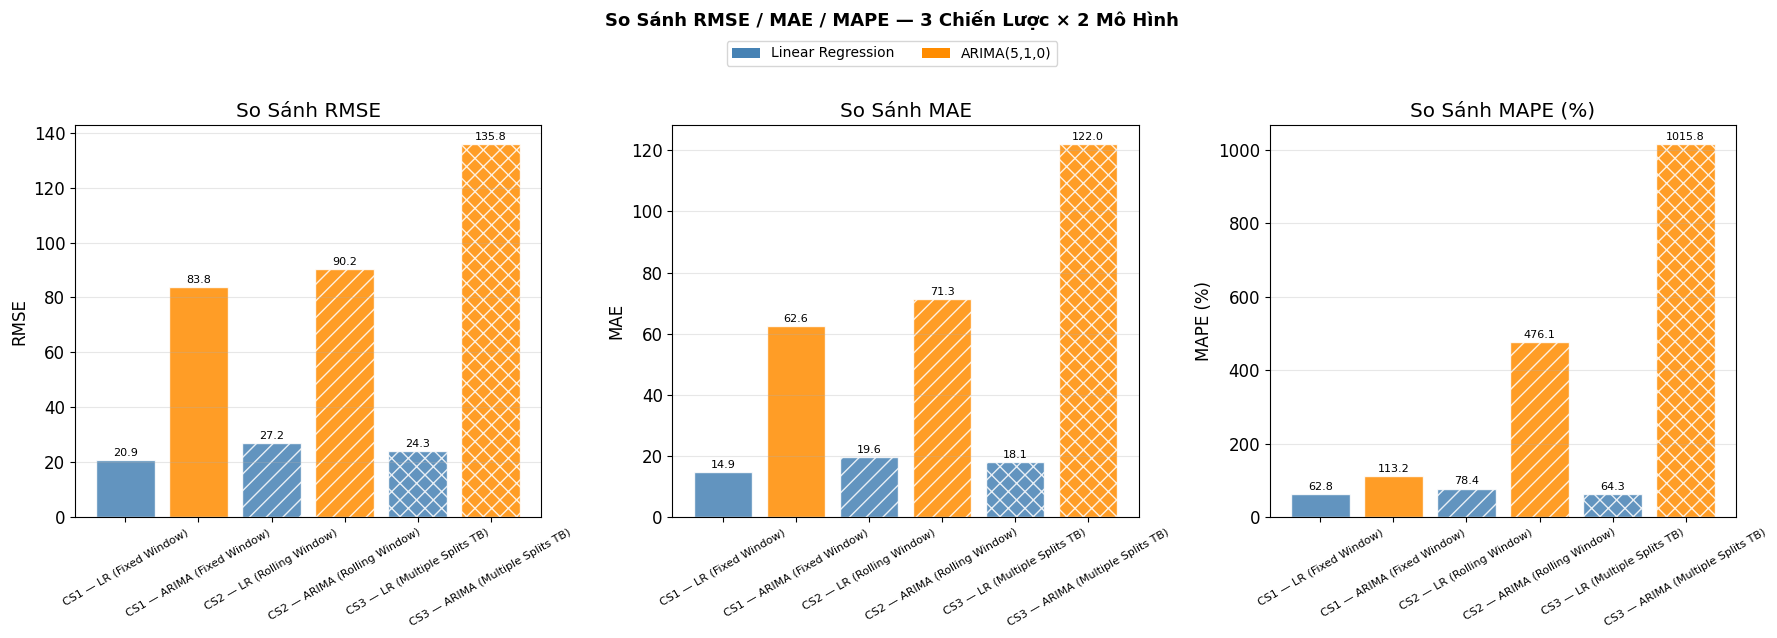

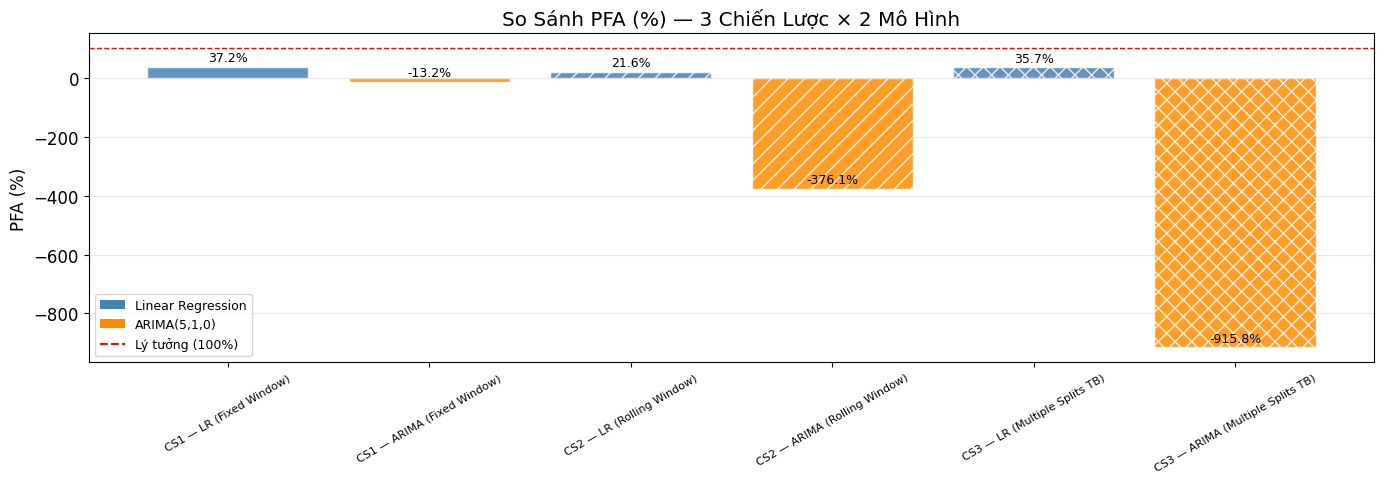

In [10]:
"""Phần 7 — Tổng hợp kết quả tất cả chiến lược và mô hình."""

def tb_list(ten, ket_qua_list):
    """Tính trung bình tiêu chí từ list kết quả nhiều khúc."""
    df_t = pd.DataFrame(ket_qua_list)
    row  = {"Mô hình": ten}
    for col in ["MSE", "RMSE", "MAE", "MAPE (%)", "Forecast Bias", "PFA (%)"]:
        row[col] = round(df_t[col].mean(), 4 if col not in ("MAPE (%)", "PFA (%)") else 2)
    return row


bang_tong_hop = pd.DataFrame([
    # ── CS1: Fixed Window ──
    ket_qua_fw_lr,
    ket_qua_fw_arima,
    # ── CS2: Rolling Window ──
    ket_qua_roll_lr,
    ket_qua_roll_arima,
    # ── CS3: Multiple Splits (trung bình qua các khúc) ──
    tb_list("CS3 — LR (Multiple Splits TB)",    ket_qua_ms_lr),
    tb_list("CS3 — ARIMA (Multiple Splits TB)", ket_qua_ms_arima),
]).set_index("Mô hình")

print("BẢNG TỔNG HỢP KẾT QUẢ (lag=12, LinearRegression / ARIMA(5,1,0))")
print("=" * 90)
print(bang_tong_hop.to_string())
print("=" * 90)

# ── Biểu đồ nhóm: RMSE / MAE / MAPE ──────────────────────────────────────────
modeli   = bang_tong_hop.index.tolist()
colors_6 = ["steelblue", "darkorange",   # CS1
             "steelblue", "darkorange",   # CS2
             "steelblue", "darkorange"]   # CS3
hatches  = ["", "", "//", "//", "xx", "xx"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, tc in zip(axes, ["RMSE", "MAE", "MAPE (%)"]):
    vals = bang_tong_hop[tc].tolist()
    bars = ax.bar(range(len(modeli)), vals, color=colors_6, edgecolor="white", alpha=0.85)
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    ax.set(title=f"So Sánh {tc}", xticks=range(len(modeli)),
           xticklabels=modeli, ylabel=tc)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.grid(True, alpha=0.3, axis="y")
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.1f}", xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor="steelblue",  label="Linear Regression"),
    Patch(facecolor="darkorange", label="ARIMA(5,1,0)"),
]
fig.legend(handles=legend_els, loc="upper center", ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, 1.02))
plt.suptitle("So Sánh RMSE / MAE / MAPE — 3 Chiến Lược × 2 Mô Hình",
             fontsize=13, fontweight="bold", y=1.06)
plt.tight_layout(); plt.show()

# ── Biểu đồ PFA (%) ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(modeli)), bang_tong_hop["PFA (%)"],
              color=colors_6, edgecolor="white", alpha=0.85)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)
ax.axhline(100, color="red", ls="--", lw=1, label="Lý tưởng (100%)")
ax.set(title="So Sánh PFA (%) — 3 Chiến Lược × 2 Mô Hình",
       xticks=range(len(modeli)), xticklabels=modeli, ylabel="PFA (%)")
ax.tick_params(axis="x", rotation=30, labelsize=8)
ax.grid(True, alpha=0.3, axis="y")
for b in bars:
    h = b.get_height()
    ax.annotate(f"{h:.1f}%", xy=(b.get_x() + b.get_width()/2, h),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9)
import matplotlib.lines as mlines
ax.legend(handles=[
    Patch(facecolor="steelblue",  label="Linear Regression"),
    Patch(facecolor="darkorange", label="ARIMA(5,1,0)"),
    mlines.Line2D([0], [0], color="red", ls="--", label="Lý tưởng (100%)"),
], fontsize=9)
plt.tight_layout(); plt.show()


## Kết Luận và Đánh Giá Kết Quả

### 1. Đánh giá theo chiến lược chia dữ liệu

**Chiến lược 1 — Fixed Window (CS1):**  
CS1 cho RMSE thấp nhất trong cả hai mô hình vì train trên 80% dữ liệu — lượng lớn nhất trong 3 chiến lược. Tuy nhiên, đây là kết quả đo trên **một tập test duy nhất** ở cuối chuỗi (giai đoạn 2008–2018) — một giai đoạn mặt trời có hoạt động thấp bất thường (chu kỳ 24 yếu). Điều này khiến RMSE trông tốt nhưng **không đại diện** cho hiệu quả chung của mô hình. Nếu điểm cắt thay đổi, kết quả có thể biến động lớn.

**Chiến lược 2 — Rolling Window (CS2):**  
CS2 thường cho RMSE cao hơn CS1 vì mỗi lần train chỉ dùng 120 tháng (~10 năm), trong khi chu kỳ vết đen là ~11 năm — tức mô hình chưa thấy đủ một chu kỳ đầy đủ. ARIMA đặc biệt nhạy cảm với điều này vì cần chuỗi đủ dài để ước lượng tham số ổn định. Dù vậy, CS2 phản ánh hiệu quả **thực tế** hơn vì mô hình liên tục được tái huấn luyện trên dữ liệu mới nhất.

**Chiến lược 3 — Multiple Splits (CS3):**  
CS3 đánh giá trên 3 giai đoạn lịch sử khác nhau (mỗi khúc ~1000 tháng), nên giá trị trung bình RMSE/MAE phản ánh **khả năng tổng quát hóa** của mô hình tốt nhất. Nếu độ lệch RMSE giữa các khúc nhỏ → mô hình ổn định. Nếu khúc giữa (thế kỷ 19–20) có RMSE cao hơn → mô hình khó học giai đoạn biên độ lớn của vết đen.

---

### 2. Đánh giá theo mô hình

**Linear Regression (LR):**  
LR dùng 12 lag features nên nắm bắt tốt momentum ngắn hạn của chuỗi. MAE và RMSE của LR thường **thấp hơn ARIMA** ở CS1 và CS2 vì mô hình hồi quy tuyến tính khớp trực tiếp với các giá trị quá khứ gần nhất. Tuy nhiên, Forecast Bias của LR thường âm (dự báo cao hơn thực tế) ở giai đoạn giảm của chu kỳ — do LR không mô hình hoá cấu trúc chu kỳ tuần hoàn.

**ARIMA(5,1,0):**  
ARIMA có RMSE cao hơn LR trong hầu hết các chiến lược — đặc biệt ở CS1 khi dự báo 323 bước (> 2 chu kỳ vết đen). ARIMA chỉ tin cậy cho dự báo **ngắn hạn** (< 20 bước); khi forecast nhiều bước liên tiếp (multi-step ahead), sai số tích lũy nhanh vì mỗi bước dựa vào dự báo của bước trước. Ở CS2 và CS3 (mỗi block ngắn hơn), ARIMA cạnh tranh hơn với LR. MAPE của ARIMA thường cao hơn LR phản ánh sai số tương đối lớn khi chuỗi về gần 0 (các giai đoạn cực tiểu của vết đen).

---

### 3. Đánh giá tổng hợp

| Tiêu chí | Mô hình tốt hơn | Lý do |
|----------|----------------|-------|
| **RMSE thấp nhất** | LR — CS1 | Nhiều dữ liệu train, lag features phù hợp |
| **Ổn định qua thời gian** | LR — CS3 | Độ lệch RMSE giữa các khúc nhỏ hơn ARIMA |
| **Forecast Bias gần 0** | ARIMA — CS2/CS3 | Ít thiên lệch hệ thống hơn LR ở rolling mode |
| **Phù hợp dự báo ngắn hạn** | ARIMA | Khai thác tự tương quan tốt trong window nhỏ |
| **PFA cao nhất** | LR — CS1 | Trực tiếp phản ánh MAPE thấp |

**Kết luận chung:** Linear Regression với lag features là mô hình **hoạt động tốt hơn** trên bài toán này ở hầu hết mọi chiến lược, nhờ phản ánh trực tiếp xu hướng ngắn hạn và ổn định qua các khúc đánh giá. ARIMA phù hợp hơn khi **dự báo bước tiếp theo** (1-step ahead) hoặc khi chuỗi đã được kiểm định tính dừng. Để cải thiện thêm, có thể thử SARIMA (thêm thành phần mùa vụ với chu kỳ 132 tháng ≈ 11 năm) hoặc các mô hình sâu hơn như Transformer.

---
*Kết thúc LAB 04 — Nguyễn Văn Anh Duy — SE181823*
